# Speed Estimation Pipeline

This notebook integrates the complete speed estimation pipeline:
1. Vehicle detection (YOLOv9)
2. Lane detection (SimpleLaneDetector)
3. Vehicle tracking (ByteTrack)
4. Homography calculation from dashed lanes
5. Speed estimation using tripwires

**Pipeline Flow:**
```
For each frame:
  1. Detect vehicles → bounding boxes
  2. Detect lanes → polylines  
  3. Track vehicles → track IDs
  4. Calculate homography → bird's-eye view
  5. Measure lane spacing → meters-per-pixel
  6. Track vehicles crossing tripwires → calculate speed
```

## 1. Setup and Imports

In [3]:
# Install dependencies
!pip install -q ultralytics opencv-python pillow matplotlib numpy scipy lap

print("Dependencies installed!")

Dependencies installed!



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
import sys
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from collections import defaultdict, deque
from ultralytics import YOLO
%matplotlib

# Add project root to path
project_root = r'D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Imports successful!")

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using matplotlib backend: module://matplotlib_inline.backend_inline
Imports successful!
Using device: cuda


## 2. Load Trained Models

### 2.1 Load Vehicle Detection Model (YOLOv9)

In [54]:
# Load YOLOv9 vehicle detection model
vehicle_model_path = r'D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\models\weights\yolov9_vehicle_detection_best.pt'

if os.path.exists(vehicle_model_path):
    vehicle_detector = YOLO(vehicle_model_path)
    print(f"Vehicle detector loaded from: {vehicle_model_path}")
else:
    print("WARNING: Vehicle detector not found. Using pretrained YOLO model.")
    vehicle_detector = YOLO('yolov8m.pt')
    print("Loaded pretrained YOLOv8m model instead.")

# Set model to evaluation mode
vehicle_detector.model.eval()
print("Vehicle detector ready!")

Vehicle detector loaded from: D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\models\weights\yolov9_vehicle_detection_best.pt
Vehicle detector ready!


### 2.2 Load Lane Detection Model

In [55]:
# Import lane detector architecture from notebook 03
from torchvision import models

class SimpleLaneDetector(nn.Module):
    def __init__(self, num_classes=1):
        super(SimpleLaneDetector, self).__init__()
        
        # Use ResNet18 as backbone
        resnet = models.resnet18(weights=None)
        
        # Encoder (ResNet backbone)
        self.layer0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1  # 64 channels
        self.layer2 = resnet.layer2  # 128 channels
        self.layer3 = resnet.layer3  # 256 channels
        self.layer4 = resnet.layer4  # 512 channels
        
        # Decoder (upsampling)
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec1 = self._make_decoder_block(512, 256)
        
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = self._make_decoder_block(256, 128)
        
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = self._make_decoder_block(128, 64)
        
        self.up4 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.dec4 = self._make_decoder_block(128, 64)
        
        # Final convolution
        self.final = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.Conv2d(32, num_classes, kernel_size=1),
            nn.Sigmoid()
        )
    
    def _make_decoder_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def _match_size(self, x, target):
        """Match spatial dimensions of x to target using interpolation"""
        if x.shape[2:] != target.shape[2:]:
            x = nn.functional.interpolate(x, size=target.shape[2:], mode='bilinear', align_corners=False)
        return x
    
    def forward(self, x):
        # Save input size for final resize
        input_size = x.shape[2:]
        
        # Encoder
        x0 = self.layer0(x)  # 1/4 size, 64 channels
        x1 = self.layer1(x0)  # 1/4 size, 64 channels
        x2 = self.layer2(x1)  # 1/8 size, 128 channels
        x3 = self.layer3(x2)  # 1/16 size, 256 channels
        x4 = self.layer4(x3)  # 1/32 size, 512 channels
        
        # Decoder with skip connections
        up1 = self.up1(x4)  # 1/16 size
        # Match sizes for concatenation
        up1 = self._match_size(up1, x3)
        cat1 = torch.cat([up1, x3], dim=1)
        dec1 = self.dec1(cat1)
        
        up2 = self.up2(dec1)  # 1/8 size
        up2 = self._match_size(up2, x2)
        cat2 = torch.cat([up2, x2], dim=1)
        dec2 = self.dec2(cat2)
        
        up3 = self.up3(dec2)  # 1/4 size
        up3 = self._match_size(up3, x1)
        cat3 = torch.cat([up3, x1], dim=1)
        dec3 = self.dec3(cat3)
        
        up4 = self.up4(dec3)  # 1/2 size
        up4 = self._match_size(up4, x0)
        cat4 = torch.cat([up4, x0], dim=1)
        dec4 = self.dec4(cat4)
        
        # Final output - upsample to original size
        out = self.final(dec4)
        
        # Ensure output matches input size exactly
        if out.shape[2:] != input_size:
            out = nn.functional.interpolate(out, size=input_size, mode='bilinear', align_corners=False)
        
        return out

print("SimpleLaneDetector architecture loaded!")

SimpleLaneDetector architecture loaded!


In [56]:
# Load lane detection model weights
lane_model_path = r'D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\models\weights\lane_detector_best.pt'

if os.path.exists(lane_model_path):
    lane_detector = SimpleLaneDetector(num_classes=1).to(device)
    lane_detector.load_state_dict(torch.load(lane_model_path, map_location=device))
    lane_detector.eval()
    print(f"Lane detector loaded from: {lane_model_path}")
else:
    print("WARNING: Lane detector not found. Will use dummy lane detection.")
    lane_detector = None

print("Lane detector ready!")

Lane detector loaded from: D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\models\weights\lane_detector_best.pt
Lane detector ready!


## 3. Homography and Scale Calculation Functions

### 3.1 Extract Lane Polylines from Segmentation Mask

In [57]:
def extract_lane_polylines(mask, threshold=0.5, min_points=10):
    """
    Extract lane polylines from segmentation mask.
    
    Args:
        mask: Binary segmentation mask (H, W)
        threshold: Threshold for binarization
        min_points: Minimum number of points for a valid lane
    
    Returns:
        List of lane polylines, each as numpy array of (x, y) points
    """
    # Binarize mask
    binary_mask = (mask > threshold).astype(np.uint8) * 255
    
    # Find contours
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    lanes = []
    for contour in contours:
        # Approximate contour
        epsilon = 0.01 * cv2.arcLength(contour, False)
        approx = cv2.approxPolyDP(contour, epsilon, False)
        
        # Convert to polyline
        points = approx.squeeze()
        
        if len(points.shape) == 2 and len(points) >= min_points:
            # Sort by y-coordinate
            points = points[np.argsort(points[:, 1])]
            lanes.append(points)
    
    return lanes

print("Lane polyline extraction function defined.")

Lane polyline extraction function defined.


### 3.2 Homography Calculation (Adapted from existing notebook)

In [59]:
def get_homography(original_image_pil, model_mask_640):
    """
    Calculate homography matrix to transform image to bird's-eye view.
    Adapted from car_and_road_recognition_model.ipynb
    """
    orig_w, orig_h = original_image_pil.size
    full_mask = cv2.resize(model_mask_640, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    
    # Find all pixels of the mask
    all_y, all_x = np.where(full_mask > 0.5)
    
    if len(all_x) == 0 or len(all_y) == 0:
        return None, None
    
    # Calculate the range of x and y axis
    delta_x = np.max(all_x) - np.min(all_x)
    delta_y = np.max(all_y) - np.min(all_y)
    
    # If delta_x is significantly larger, we treat it as horizontal
    if delta_x > 1.2 * delta_y:
        # Horizontal roads, we take dots on the left and right side
        offset_x = int(delta_x * 0.1)
        left_x = np.min(all_x) + offset_x
        right_x = np.max(all_x) - offset_x
        
        # Edges of the road are on the top and bottom of that x
        left_indices = np.where(full_mask[:, left_x] > 0.5)[0]
        right_indices = np.where(full_mask[:, right_x] > 0.5)[0]
        
        if len(left_indices) == 0 or len(right_indices) == 0:
            return None, None
        
        # Ordering points for 400x800 vertical output
        src_pts = np.float32([
            [left_x, left_indices[0]],   
            [right_x, right_indices[0]], 
            [right_x, right_indices[-1]],
            [left_x, left_indices[-1]]   
        ])
    else:
        # Vertical road
        top_y = np.min(all_y) + 30
        bottom_y = np.max(all_y) - 20
        top_indices = np.where(full_mask[top_y, :] > 0.5)[0]
        bottom_indices = np.where(full_mask[bottom_y, :] > 0.5)[0]
        
        if len(top_indices) == 0 or len(bottom_indices) == 0:
            return None, None
        
        src_pts = np.float32([
            [top_indices[0], top_y], 
            [top_indices[-1], top_y],
            [bottom_indices[-1], bottom_y], 
            [bottom_indices[0], bottom_y]
        ])

    # Rotate the image to a bird's eye view
    dst_pts = np.float32([[0, 0], [400, 0], [400, 800], [0, 800]])
    M = cv2.getPerspectiveTransform(src_pts, dst_pts)
    warped = cv2.warpPerspective(np.array(original_image_pil), M, (400, 800))
    
    return warped, M

print("Homography calculation function defined.")

Homography calculation function defined.


### 3.3 Extract Line Segments from Dashed Lanes

In [60]:
def extract_line_segments(warped_img):
    """
    Extract line segments from warped bird's-eye view image.
    Adapted from car_and_road_recognition_model.ipynb
    """
    # Grayscale the image
    gray = cv2.cvtColor(warped_img, cv2.COLOR_RGB2GRAY)
    # Otsu threshold for extracting lines
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    height, width = thresh.shape
    
    # Find the best x axis by looking for dashed lines
    best_x = width // 2
    max_score = 0
    best_segments = []
    
    # Scan from left to right, staying away from sidewalk edges
    for x in range(50, width - 50, 10):
        # Create the tunnel around current x
        sample_width = 5
        tunnel = thresh[:, max(0, x - sample_width) : min(width, x + sample_width)]
        
        # Average of the tunnel to boolean
        line_map = np.mean(tunnel, axis=1) > 127
        
        # Group into segments
        segments = []
        if len(line_map) > 0:
            count = 1
            for i in range(1, len(line_map)):
                if line_map[i] == line_map[i-1]:
                    count += 1
                else:
                    segments.append((line_map[i-1], count))
                    count = 1
            segments.append((line_map[-1], count))
            
            # Score to avoid tram rails or long curbs
            transitions = len(segments)
            score = transitions
            
            for is_white, length in segments:
                # If the white line is too long (more than 40% of height), it's probably a rail
                if is_white and length > (height * 0.4):
                    score = 0
                    break
            
            # Take the x with best score
            if score > max_score:
                max_score = score
                best_x = x
                best_segments = segments
                
    if not best_segments: 
        return None, None, best_x
        
    # Find the first valid couple
    p_line, p_gap = None, None
    for i in range(len(best_segments) - 1):
        # Use a safe range for lines (30px to 300px)
        if best_segments[i][0] == True and 30 < best_segments[i][1] < 300:
            if best_segments[i+1][0] == False and 20 < best_segments[i+1][1] < 400:
                p_line = best_segments[i][1]
                p_gap = best_segments[i+1][1]
                break
                
    return p_line, p_gap, best_x

print("Line segment extraction function defined.")

Line segment extraction function defined.


### 3.4 Calculate Meters per Pixel

In [61]:
def calculate_meters_per_pixel(p_line, p_gap, verbose=False):
    """
    Calculate scale factor (meters per pixel) from dashed lane markings.
    Adapted from car_and_road_recognition_model.ipynb
    """
    if p_line is None or p_gap is None:
        if verbose:
            print("System did not detect a clear line-gap pair.")
        return None
        
    ratio = p_line / p_gap
    
    # If the line is a lot bigger than the gap, we say it's 3m line and 1m gap
    if ratio >= 2.0:
        road_type = "City road (3m line, 1m gap)"
        meters_per_pixel = 3.0 / p_line
    else:
        road_type = "Open road (3m line, 3m gap)"
        meters_per_pixel = 3.0 / p_line
        
    # Safety check
    if meters_per_pixel > 0.5:
        if verbose:
            print("Warning: Scale factor is suspiciously large!")
        return None
        
    if verbose:
        print(f"Road type: {road_type}")
        print(f"Pixels: Line={p_line}px, Gap={p_gap}px (Ratio: {ratio:.2f})")
        print(f"Final scale: {meters_per_pixel:.5f} meters per pixel")
    
    return meters_per_pixel

print("Meters per pixel calculation function defined.")

Meters per pixel calculation function defined.


## 4. Simple Tracking Implementation

### 4.1 Simple IoU-Based Tracker (Lightweight Alternative to ByteTrack)

In [62]:
def calculate_iou(box1, box2):
    """
    Calculate Intersection over Union (IoU) between two boxes.
    Boxes in format [x1, y1, x2, y2]
    """
    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])
    
    if x2_inter < x1_inter or y2_inter < y1_inter:
        return 0.0
    
    inter_area = (x2_inter - x1_inter) * (y2_inter - y1_inter)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area
    
    return inter_area / union_area if union_area > 0 else 0.0

class SimpleTracker:
    """
    Simple IoU-based tracker for vehicles.
    """
    def __init__(self, iou_threshold=0.3, max_age=30):
        self.iou_threshold = iou_threshold
        self.max_age = max_age
        self.tracks = {}
        self.next_id = 1
        self.frame_count = 0
    
    def update(self, detections):
        """
        Update tracks with new detections.
        
        Args:
            detections: List of [x1, y1, x2, y2, confidence, class_id]
        
        Returns:
            List of [x1, y1, x2, y2, track_id, class_id]
        """
        self.frame_count += 1
        
        # Match detections to existing tracks
        matched_tracks = {}
        unmatched_detections = list(range(len(detections)))
        
        # Try to match each track
        for track_id, track_data in list(self.tracks.items()):
            best_iou = 0
            best_det_idx = -1
            
            for det_idx in unmatched_detections:
                det_box = detections[det_idx][:4]
                track_box = track_data['box']
                iou = calculate_iou(track_box, det_box)
                
                if iou > best_iou and iou > self.iou_threshold:
                    best_iou = iou
                    best_det_idx = det_idx
            
            if best_det_idx >= 0:
                # Match found
                det = detections[best_det_idx]
                self.tracks[track_id] = {
                    'box': det[:4],
                    'class_id': int(det[5]) if len(det) > 5 else 0,
                    'last_seen': self.frame_count
                }
                matched_tracks[track_id] = det[:4]
                unmatched_detections.remove(best_det_idx)
        
        # Create new tracks for unmatched detections
        for det_idx in unmatched_detections:
            det = detections[det_idx]
            track_id = self.next_id
            self.next_id += 1
            self.tracks[track_id] = {
                'box': det[:4],
                'class_id': int(det[5]) if len(det) > 5 else 0,
                'last_seen': self.frame_count
            }
            matched_tracks[track_id] = det[:4]
        
        # Remove old tracks
        to_remove = []
        for track_id, track_data in self.tracks.items():
            if self.frame_count - track_data['last_seen'] > self.max_age:
                to_remove.append(track_id)
        
        for track_id in to_remove:
            del self.tracks[track_id]
        
        # Return tracked objects
        tracked_objects = []
        for track_id, box in matched_tracks.items():
            class_id = self.tracks[track_id]['class_id']
            tracked_objects.append([*box, track_id, class_id])
        
        return tracked_objects

print("SimpleTracker defined!")

SimpleTracker defined!


## 6. Complete Pipeline Integration

In [83]:
# class SpeedEstimationPipeline:
#     def __init__(self, vehicle_detector, lane_detector, fps=30):
#         self.vehicle_detector = vehicle_detector
#         self.lane_detector = lane_detector
#         self.fps = fps
        
#         self.tracker = SimpleTracker(iou_threshold=0.3, max_age=30)
        
#         # Caching
#         self.homography_matrix = None
#         self.meters_per_pixel = None
#         self.frame_count = 0

#         # Track history (BEV positions)
#         self.track_history = defaultdict(lambda: deque(maxlen=20)) # Increased for stability
#         self.track_speeds = defaultdict(lambda: deque(maxlen=20))
    
#     def process_frame(self, frame):
#         h, w = frame.shape[:2]
#         lanes = []
#         lane_mask = None
    
#         # 1. Detect vehicles (Always needed)
#         vehicle_results = self.vehicle_detector.predict(frame, conf=0.25, iou=0.45, verbose=False)[0]
#         detections = [[*box.xyxy[0].cpu().numpy(), box.conf[0].cpu().numpy(), int(box.cls[0].cpu().numpy())] 
#                       for box in vehicle_results.boxes]
    
#         # 2. Detect lanes & Homography (ONLY if not already cached)
#         if self.homography_matrix is None or self.meters_per_pixel is None:
#             if self.lane_detector is not None:
#                 from torchvision import transforms
#                 transform = transforms.Compose([
#                     transforms.ToPILImage(),
#                     transforms.Resize((640, 640)),
#                     transforms.ToTensor()
#                 ])
#                 # Note: Frame should be RGB here
#                 image_tensor = transform(frame).unsqueeze(0).to(device)
#                 with torch.no_grad():
#                     raw_mask = self.lane_detector(image_tensor)
#                     lane_mask = torch.sigmoid(raw_mask).squeeze().cpu().numpy()
                
#                 lanes = extract_lane_polylines(lane_mask, threshold=0.58, min_points=3)
                
#                 if len(lanes) > 0:
#                     try:
#                         pil_image = Image.fromarray(frame)
#                         warped, M = get_homography(pil_image, lane_mask)
#                         if warped is not None and M is not None:
#                             p_line, p_gap, _ = extract_line_segments(warped)
#                             mpp = calculate_meters_per_pixel(p_line, p_gap)
#                             if mpp is not None:
#                                 self.homography_matrix = M
#                                 self.meters_per_pixel = mpp
#                                 print(f"--- SUCCESS: Scale Fixed at {mpp:.5f} MPP ---")
#                     except Exception as e:
#                         print(f"Homography error: {e}")

#         # 3. Track vehicles
#         tracked_objects = self.tracker.update(detections)
    
#         # 4. Calculate speed
#         speeds = {}
#         for obj in tracked_objects:
#             x1, y1, x2, y2, track_id, class_id = obj
            
#             # Use bottom-center for better perspective accuracy
#             cx, cy = (x1 + x2) / 2, y2
    
#             if self.homography_matrix is None or self.meters_per_pixel is None:
#                 continue
    
#             # Transform to Bird's Eye View
#             point = np.array([[[cx, cy]]], dtype=np.float32)
#             bev_point = cv2.perspectiveTransform(point, self.homography_matrix)[0][0]
#             self.track_history[track_id].append((self.frame_count, bev_point))
    
#             # Wait for at least 5 frames of history to calculate speed reliably
#             if len(self.track_history[track_id]) < 5:
#                 continue
    
#             # IMPROVEMENT: Calculate speed between first and last point in history
#             # This smooths out frame-to-frame jitter
#             history = list(self.track_history[track_id])
#             (f_start, p_start), (f_end, p_end) = history[0], history[-1]
            
#             pixel_distance = np.linalg.norm(p_end - p_start)
#             dt = (f_end - f_start) / self.fps
            
#             if dt > 0:
#                 meters = pixel_distance * self.meters_per_pixel
#                 speed_kmh_raw = (meters / dt) * 3.6
                
#                 # Filter out impossible jumps
#                 if 5 < speed_kmh_raw < 220:
#                     self.track_speeds[track_id].append(speed_kmh_raw)
#                     speeds[track_id] = float(np.mean(self.track_speeds[track_id]))
    
#         self.frame_count += 1
#         return {'vehicles': tracked_objects, 'lanes': lanes, 'speeds': speeds}

## 7. Testing and Visualization

### 7.2 Process Test Video

In [85]:
# # Initialize pipeline
# pipeline = SpeedEstimationPipeline(vehicle_detector, lane_detector, fps=30)

# # Open test video
# cap = cv2.VideoCapture("VID_20260311_085632.mp4")

# # Process frames
# frame_count = 0
# all_speeds = []

# print("Processing video...")

# while cap.isOpened():
#     ret, frame = cap.read()
#     if not ret:
#         break
    
#     # Convert BGR to RGB
#     # frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
#     # Process frame
#     results = pipeline.process_frame(frame)
    
#     # Collect speeds
#     for track_id, speed in results['speeds'].items():
#         all_speeds.append({'track_id': track_id, 'speed_kmh': speed, 'frame': frame_count})
    
#     frame_count += 1
    
#     if frame_count % 10 == 0:
#         print(f"Processed {frame_count} frames...")

# cap.release()

# print(f"\nProcessing complete!")
# print(f"Total frames processed: {frame_count}")
# print(f"Speeds calculated: {len(all_speeds)}")

## 8. Export Results

In [87]:
# import json

# # Format results for export
# export_data = []

# for speed_data in all_speeds:
#     export_data.append({
#         "track_id": int(speed_data['track_id']),
#         "speed_kmh": float(speed_data['speed_kmh']),
#         "frame": int(speed_data['frame']),
#         "confidence": 0.85  # Placeholder confidence
#     })

# # Save to JSON
# output_json_path = r'D:/PODACI SA C/ROOT/Projekti/singi-ml/SpeedRadarProject/speed-radar/speed_estimations.json'
# with open(output_json_path, 'w') as f:
#     json.dump(export_data, f, indent=2)

# print(f"Results exported to: {output_json_path}")
# print(f"Total speed measurements: {len(export_data)}")

# # Display sample results
# if len(export_data) > 0:
#     print("\nSample results:")
#     for i, result in enumerate(export_data[:5]):
#         print(f"  {i+1}. Track ID: {result['track_id']}, Speed: {result['speed_kmh']:.1f} km/h, Frame: {result['frame']}")

In [93]:
import cv2
import torch
import numpy as np
import json
from PIL import Image
from collections import defaultdict, deque

class SpeedEstimationPipeline:
    def __init__(self, vehicle_detector, lane_detector, fps=30):
        self.vehicle_detector = vehicle_detector
        self.lane_detector = lane_detector
        self.fps = fps
        self.tracker = SimpleTracker(iou_threshold=0.3, max_age=30)
        
        # Caching
        self.homography_matrix = None
        self.meters_per_pixel = None
        self.frame_count = 0

        # Track history
        self.track_history = defaultdict(lambda: deque(maxlen=20))
        self.track_speeds = defaultdict(lambda: deque(maxlen=20))
    
    def process_frame(self, frame):
        h, w = frame.shape[:2]
        lanes = []
    
        # 1. Detect vehicles
        vehicle_results = self.vehicle_detector.predict(frame, conf=0.25, iou=0.45, verbose=False)[0]
        detections = [[*box.xyxy[0].cpu().numpy(), box.conf[0].cpu().numpy(), int(box.cls[0].cpu().numpy())] 
                      for box in vehicle_results.boxes]

        # 2. Detect lanes & Homography (ONLY if not already cached)
        if self.homography_matrix is None or self.meters_per_pixel is None:
            if self.lane_detector is not None:
                from torchvision import transforms
                transform = transforms.Compose([
                    transforms.ToPILImage(),
                    transforms.Resize((640, 640)),
                    transforms.ToTensor()
                ])
                
                # Use RGB for lane detection
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                image_tensor = transform(frame_rgb).unsqueeze(0).to(next(self.lane_detector.parameters()).device)
                
                with torch.no_grad():
                    raw_mask = self.lane_detector(image_tensor)
                    lane_mask = torch.sigmoid(raw_mask).squeeze().cpu().numpy()
                
                lanes = extract_lane_polylines(lane_mask, threshold=0.58, min_points=3)
                
                if len(lanes) > 0:
                    try:
                        pil_image = Image.fromarray(frame_rgb)
                        warped, M = get_homography(pil_image, lane_mask)
                        
                        if warped is not None and M is not None:
                            p_line, p_gap, _ = extract_line_segments(warped)
                            mpp = calculate_meters_per_pixel(p_line, p_gap)
                            
                            if mpp is not None:
                                self.homography_matrix = M
                                self.meters_per_pixel = mpp
                                print(f"--- SUCCESS: Scale Fixed at {mpp:.5f} MPP ---")
                    except Exception as e:
                        print(f"Homography error at frame {self.frame_count}: {e}")

        # 3. Track vehicles
        tracked_objects = self.tracker.update(detections)
    
        # 4. Calculate speed
        speeds = {}
        vehicles_with_speed = []

        for obj in tracked_objects:
            x1, y1, x2, y2, track_id, class_id = obj
            cx, cy = (x1 + x2) / 2, y2 # Bottom-center
            
            current_speed = None
            
            # Only calculate if we have the road scale
            if self.homography_matrix is not None and self.meters_per_pixel is not None:
                point = np.array([[[cx, cy]]], dtype=np.float32)
                bev_point = cv2.perspectiveTransform(point, self.homography_matrix)[0][0]
                self.track_history[track_id].append((self.frame_count, bev_point))
    
                # Calculate speed over a 5-frame window for stability
                if len(self.track_history[track_id]) >= 5:
                    history = list(self.track_history[track_id])
                    (f_start, p_start), (f_end, p_end) = history[0], history[-1]
                    
                    pixel_distance = np.linalg.norm(p_end - p_start)
                    dt = (f_end - f_start) / self.fps
                    
                    if dt > 0:
                        meters = pixel_distance * self.meters_per_pixel
                        speed_kmh_raw = (meters / dt) * 3.6
                        
                        # Filter outliers
                        if 5 < speed_kmh_raw < 220:
                            self.track_speeds[track_id].append(speed_kmh_raw)
                            current_speed = float(np.mean(self.track_speeds[track_id]))
                            speeds[track_id] = current_speed

            vehicles_with_speed.append((x1, y1, x2, y2, track_id, class_id, current_speed))
    
        self.frame_count += 1
        return {'vehicles': vehicles_with_speed, 'lanes': lanes, 'speeds': speeds}

# --- EXECUTION LOOP ---
video_path = "VID_20260311_085632.mp4"
cap = cv2.VideoCapture(video_path)

# Dynamic FPS
video_fps = cap.get(cv2.CAP_PROP_FPS)
if video_fps < 1: video_fps = 30.0

pipeline = SpeedEstimationPipeline(vehicle_detector, lane_detector, fps=video_fps)
all_speeds = []

print(f"Processing video at {video_fps:.2f} FPS...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    results = pipeline.process_frame(frame)
    
    # Store results for export
    for track_id, speed in results['speeds'].items():
        all_speeds.append({
            'track_id': track_id, 
            'speed_kmh': speed, 
            'frame': pipeline.frame_count
        })

cap.release()

# --- FINAL PER-CAR EXPORT ---
car_stats = defaultdict(list)
for entry in all_speeds:
    car_stats[entry['track_id']].append(entry['speed_kmh'])

export_data = []
for track_id, speeds in car_stats.items():
    if len(speeds) < 3: continue 
    export_data.append({
        "track_id": int(track_id),
        "avg_speed": round(float(np.mean(speeds)), 1),
        "max_speed": round(float(np.max(speeds)), 1),
        "min_speed": round(float(np.min(speeds)), 1)
    })

# Save to JSON
output_path = 'speed_summary_per_car.json'
with open(output_path, 'w') as f:
    json.dump(export_data, f, indent=2)

print(f"Finished. Exported {len(export_data)} cars to {output_path}")

Processing video at 30.01 FPS...
--- SUCCESS: Scale Fixed at 0.02703 MPP ---
Finished. Exported 5 cars to speed_summary_per_car.json


In [96]:
import cv2
import torch
import numpy as np
import json
import os
from PIL import Image
from collections import defaultdict, deque

class SpeedEstimationPipeline:
    def __init__(self, vehicle_detector, lane_detector, fps=30, crops_dir="vehicle_crops"):
        self.vehicle_detector = vehicle_detector
        self.lane_detector = lane_detector
        self.fps = fps
        self.tracker = SimpleTracker(iou_threshold=0.3, max_age=30)
        
        # Folder for images
        self.crops_dir = crops_dir
        os.makedirs(self.crops_dir, exist_ok=True)
        self.saved_crop_ids = set() 

        # Caching and History
        self.homography_matrix = None
        self.meters_per_pixel = None
        self.frame_count = 0
        self.track_history = defaultdict(lambda: deque(maxlen=20))
        self.track_speeds = defaultdict(lambda: deque(maxlen=20))
    
    def process_frame(self, frame):
        h, w = frame.shape[:2]
        lanes = []
        
        # 1. Detect vehicles
        vehicle_results = self.vehicle_detector.predict(frame, conf=0.25, iou=0.45, verbose=False)[0]
        detections = [[*box.xyxy[0].cpu().numpy(), box.conf[0].cpu().numpy(), int(box.cls[0].cpu().numpy())] 
                      for box in vehicle_results.boxes]

        # 2. Lane Detection & Homography (Calculated once)
        if self.homography_matrix is None or self.meters_per_pixel is None:
            if self.lane_detector is not None:
                from torchvision import transforms
                transform = transforms.Compose([transforms.ToPILImage(), transforms.Resize((640, 640)), transforms.ToTensor()])
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                image_tensor = transform(frame_rgb).unsqueeze(0).to(next(self.lane_detector.parameters()).device)
                
                with torch.no_grad():
                    raw_mask = self.lane_detector(image_tensor)
                    lane_mask = torch.sigmoid(raw_mask).squeeze().cpu().numpy()
                
                lanes = extract_lane_polylines(lane_mask, threshold=0.58, min_points=3)
                if len(lanes) > 0:
                    try:
                        pil_image = Image.fromarray(frame_rgb)
                        warped, M = get_homography(pil_image, lane_mask)
                        if warped is not None and M is not None:
                            p_line, p_gap, _ = extract_line_segments(warped)
                            mpp = calculate_meters_per_pixel(p_line, p_gap)
                            if mpp:
                                self.homography_matrix, self.meters_per_pixel = M, mpp
                                print(f"--- SUCCESS: Scale Found at {mpp:.5f} MPP ---")
                    except Exception as e: print(f"Scaling error: {e}")

        # 3. Track vehicles
        tracked_objects = self.tracker.update(detections)
    
        # 4. Calculate speed
        speeds = {}
        for obj in tracked_objects:
            x1, y1, x2, y2, track_id, class_id = obj
            cx, cy = (x1 + x2) / 2, y2 

            if self.homography_matrix is not None:
                point = np.array([[[cx, cy]]], dtype=np.float32)
                bev_point = cv2.perspectiveTransform(point, self.homography_matrix)[0][0]
                self.track_history[track_id].append((self.frame_count, bev_point))
                
                if len(self.track_history[track_id]) >= 5:
                    hist = list(self.track_history[track_id])
                    (f_start, p_start), (f_end, p_end) = hist[0], hist[-1]
                    dist = np.linalg.norm(p_end - p_start) * self.meters_per_pixel
                    dt = (f_end - f_start) / self.fps
                    
                    if dt > 0:
                        speed = (dist / dt) * 3.6
                        
                        # --- VALID SPEED FOUND ---
                        if 5 < speed < 220:
                            self.track_speeds[track_id].append(speed)
                            speeds[track_id] = float(np.mean(self.track_speeds[track_id]))

                            # --- NEW: Save Screenshot ONLY now that speed is verified ---
                            if track_id not in self.saved_crop_ids:
                                pad = 10
                                c_x1, c_y1 = max(0, int(x1)-pad), max(0, int(y1)-pad)
                                c_x2, c_y2 = min(w, int(x2)+pad), min(h, int(y2)+pad)
                                
                                car_crop = frame[c_y1:c_y2, c_x1:c_x2]
                                if car_crop.size > 0:
                                    crop_name = f"car_{int(track_id)}.jpg"
                                    cv2.imwrite(os.path.join(self.crops_dir, crop_name), car_crop)
                                    self.saved_crop_ids.add(track_id)

        self.frame_count += 1
        return {'speeds': speeds}

# --- EXECUTION ---
video_path = "VID_20260311_085632.mp4"
cap = cv2.VideoCapture(video_path)
video_fps = cap.get(cv2.CAP_PROP_FPS) or 30.0

pipeline = SpeedEstimationPipeline(vehicle_detector, lane_detector, fps=video_fps)
all_measurements = []

print(f"Analyzing video ({video_fps:.2f} FPS)...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break
    
    results = pipeline.process_frame(frame)
    
    for tid, s in results['speeds'].items():
        all_measurements.append({'id': tid, 'speed': s})

cap.release()

# --- EXPORT ---
car_data = defaultdict(list)
for m in all_measurements:
    car_data[m['id']].append(m['speed'])

final_json = []
for tid, speeds in car_data.items():
    # Only export cars that reached the minimum sample count
    if len(speeds) >= 3:
        final_json.append({
            "track_id": int(tid),
            "average_speed": round(float(np.mean(speeds)), 1),
            "max_speed": round(float(np.max(speeds)), 1),
            "image_filename": f"car_{int(tid)}.jpg"
        })

with open('final_speed_report.json', 'w') as f:
    json.dump(final_json, f, indent=2)

print(f"Done! {len(final_json)} valid cars exported with matching cutouts.")

Analyzing video (30.01 FPS)...
--- SUCCESS: Scale Found at 0.02703 MPP ---
Done! 5 valid cars exported with matching cutouts.


## 9. Statistics and Validation

SPEED ESTIMATION STATISTICS

Total measurements: 221
Average speed: 12.08 km/h
Median speed: 12.09 km/h
Min speed: 7.75 km/h
Max speed: 13.58 km/h
Std deviation: 1.18 km/h


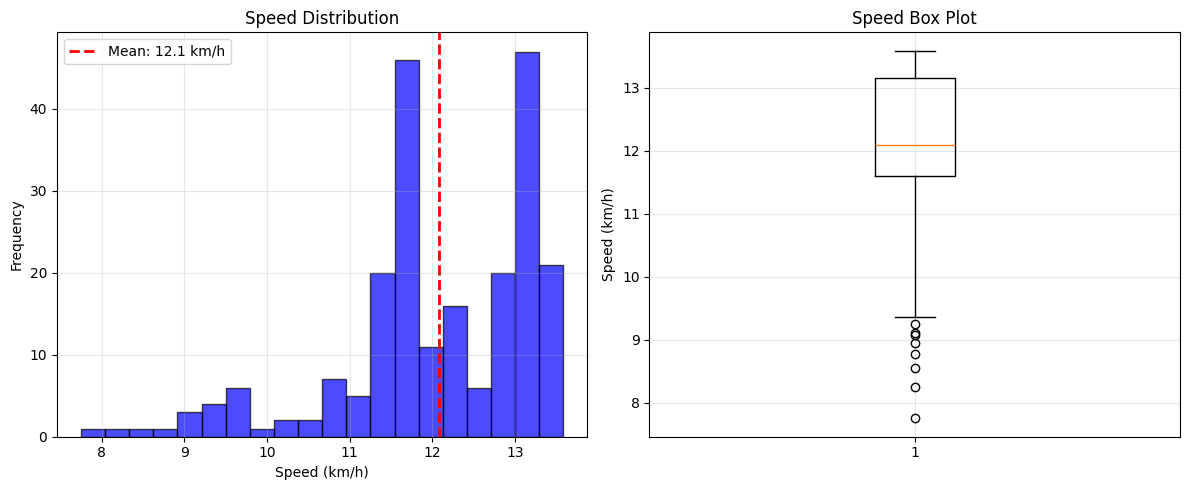


VALIDATION:



In [80]:
# Calculate statistics
if len(all_speeds) > 0:
    speeds_only = [s['speed_kmh'] for s in all_speeds]
    
    print("="*70)
    print("SPEED ESTIMATION STATISTICS")
    print("="*70)
    
    print(f"\nTotal measurements: {len(speeds_only)}")
    print(f"Average speed: {np.mean(speeds_only):.2f} km/h")
    print(f"Median speed: {np.median(speeds_only):.2f} km/h")
    print(f"Min speed: {np.min(speeds_only):.2f} km/h")
    print(f"Max speed: {np.max(speeds_only):.2f} km/h")
    print(f"Std deviation: {np.std(speeds_only):.2f} km/h")
    
    # Plot distribution
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(speeds_only, bins=20, color='blue', alpha=0.7, edgecolor='black')
    plt.axvline(np.mean(speeds_only), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(speeds_only):.1f} km/h')
    plt.xlabel('Speed (km/h)')
    plt.ylabel('Frequency')
    plt.title('Speed Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.boxplot(speeds_only)
    plt.ylabel('Speed (km/h)')
    plt.title('Speed Box Plot')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Validation check
    print("\nVALIDATION:")
    if 30 <= np.mean(speeds_only) <= 80:
        print("  Average speed is within expected range for city streets (30-80 km/h)")
    else:
        print("  WARNING: Average speed is outside expected range. Check calibration.")
    
    print("\n" + "="*70)
else:
    print("No speed measurements were calculated.")
    print("This may indicate:")
    print("  1. Lane detection failed (no dashed lanes detected)")
    print("  2. Vehicles did not cross both tripwires")
    print("  3. Homography calculation failed")